In [1]:
import pandas as pd
import numpy as np
import os
import joblib 
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder

# Set plotting style for consistent output
sns.set_style("whitegrid")

In [2]:
# --- 1. Settings and Data Loading (Defining the DataFrame) ---
print("--- Starting 05 Quick Baseline Model & Feature Importance (Scikit-learn DTR) ---")

# Define the relative path to the cleaned Parquet file created in 03_final_prep.ipynb
# This structure assumes the script is run from a notebook folder (e.g., /notebooks/05...)
PROCESSED_DATA_PATH = './../../data/electricity/processed/demand_model_ready.parquet'
MODEL_PATH = './../../data/trained_models/electricity/'

try:
    # Use pandas (pd) to load the model-ready DataFrame. This defines the 'df' variable.
    resolved_path = os.path.normpath(PROCESSED_DATA_PATH)
    print(f"1. Loading cleaned data from resolved path: {resolved_path}")
    df = pd.read_parquet(resolved_path)
    print(f"   -> Data successfully loaded. Total records: {len(df):,}")
    
    # Check if the dataframe is empty after loading
    if df.empty:
        raise ValueError("Loaded DataFrame is empty. Check 03_final_prep.ipynb output.")

except FileNotFoundError:
    print(f"   -> ERROR: File not found at {PROCESSED_DATA_PATH}. Please run 03_final_prep.ipynb first.")
    exit()
except Exception as e:
    print(f"   -> An error occurred during data loading: {e}")
    exit()


--- Starting 05 Quick Baseline Model & Feature Importance (Scikit-learn DTR) ---
1. Loading cleaned data from resolved path: ../../data/electricity/processed/demand_model_ready.parquet
   -> Data successfully loaded. Total records: 434,590


In [15]:
# --- 2. Feature and Target Preparation ---

# Asegúrate de que SETTLEMENT_DATE es datetime
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'])

# 1. Crear nuevas características numéricas basadas en la fecha
# Esto soluciona el error "float() argument..."
df['Month'] = df['SETTLEMENT_DATE'].dt.month
df['Day'] = df['SETTLEMENT_DATE'].dt.day
df['DayOfWeek'] = df['SETTLEMENT_DATE'].dt.dayofweek  # 0=Lunes, 6=Domingo

# Target variable (y)
y = np.log(df['ND'])

# Features (X): 
# HE ELIMINADO: 'ND', 'TSD', 'ENGLAND_WALES_DEMAND' (para evitar Data Leakage)
# SOLO DEJAMOS: Variables de calendario que conocemos por adelantado.
features = ['Month', 'Day', 'DayOfWeek', 'SETTLEMENT_PERIOD', 'Year']

X = df[features].copy()

# Identify categorical features (aunque ahora casi todo es numérico, year podría ser cat)
categorical_features = [col for col in X.columns if X[col].dtype.name == 'category']

In [16]:
# --- 3. Categorical Feature Encoding (MANDATORY for base Scikit-learn models) ---

print("\n3. Encoding categorical features using OrdinalEncoder...")
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_features] = encoder.fit_transform(X[categorical_features])
print("   -> Encoding complete. All features are now numerical.")


3. Encoding categorical features using OrdinalEncoder...
   -> Encoding complete. All features are now numerical.


In [17]:
# --- 4. Data Splitting (Train/Test) ---

# Use 80/20 split for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"4. Data Split (80/20):")
print(f"   -> Training samples: {len(X_train):,}")
print(f"   -> Testing samples: {len(X_test):,}")

4. Data Split (80/20):
   -> Training samples: 347,672
   -> Testing samples: 86,918


In [18]:
# --- 5. Decision Tree Model Training (Quick Baseline) ---

# Decision Tree Regressor is fast and simple for a quick baseline.
# Max depth is limited to prevent extreme overfitting and save memory.
dtr_reg = DecisionTreeRegressor(
    max_depth=10, 
    random_state=42
)

print("\n5. Training Scikit-learn Decision Tree Model (Quick Baseline - Max Depth 10)...")
dtr_reg.fit(X_train, y_train)
print("   -> Training complete.")


5. Training Scikit-learn Decision Tree Model (Quick Baseline - Max Depth 10)...
   -> Training complete.


In [19]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# --- 6. Model Evaluation (Decision Tree) ---

# 1. Generar predicciones (el modelo predice en escala logarítmica)
y_pred_log = dtr_reg.predict(X_test)

# 2. Invertir la transformación para volver a la escala original (Demanda real)
# Usamos np.exp() porque entrenaste con np.log()
y_test_demand = np.exp(y_test)
y_pred_demand = np.exp(y_pred_log)

# 3. Calcular métricas en la escala original
rmse_demand = np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))
mae_demand = mean_absolute_error(y_test_demand, y_pred_demand) # Error absoluto medio
r2_demand = r2_score(y_test_demand, y_pred_demand)

# 4. Calcular métricas en escala logarítmica (útil para diagnóstico técnico)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

print("\n6. Model Evaluation Metrics (Test Set - National Demand):")
print("-" * 60)
print(f"R^2 Score (Log Scale)    : {r2_log:.4f}")
print(f"RMSE (Log Scale)         : {rmse_log:.4f}")
print("-" * 60)
print(f"R^2 Score (Actual Demand): {r2_demand:.4f}")
print(f"RMSE (Actual Demand)     : {rmse_demand:,.2f} MW (Root Mean Squared Error)")
print(f"MAE  (Actual Demand)     : {mae_demand:,.2f} MW (Mean Absolute Error)")
print("-" * 60)

# Verificación rápida visual de los primeros 5 valores
print("\nCheck first 5 predictions vs actuals:")
comparison = pd.DataFrame({
    'Actual (MW)': y_test_demand[:5].values,
    'Predicted (MW)': y_pred_demand[:5]
})
print(comparison)


6. Model Evaluation Metrics (Test Set - National Demand):
------------------------------------------------------------
R^2 Score (Log Scale)    : 0.9285
RMSE (Log Scale)         : 0.0705
------------------------------------------------------------
R^2 Score (Actual Demand): 0.9264
RMSE (Actual Demand)     : 2,314.28 MW (Root Mean Squared Error)
MAE  (Actual Demand)     : 1,726.17 MW (Mean Absolute Error)
------------------------------------------------------------

Check first 5 predictions vs actuals:
   Actual (MW)  Predicted (MW)
0      30078.0    32083.648933
1      27015.0    27632.821932
2      32890.0    44990.112654
3      30751.0    32420.607138
4      18873.0    17671.291147



6b. Generating Residual Plots...


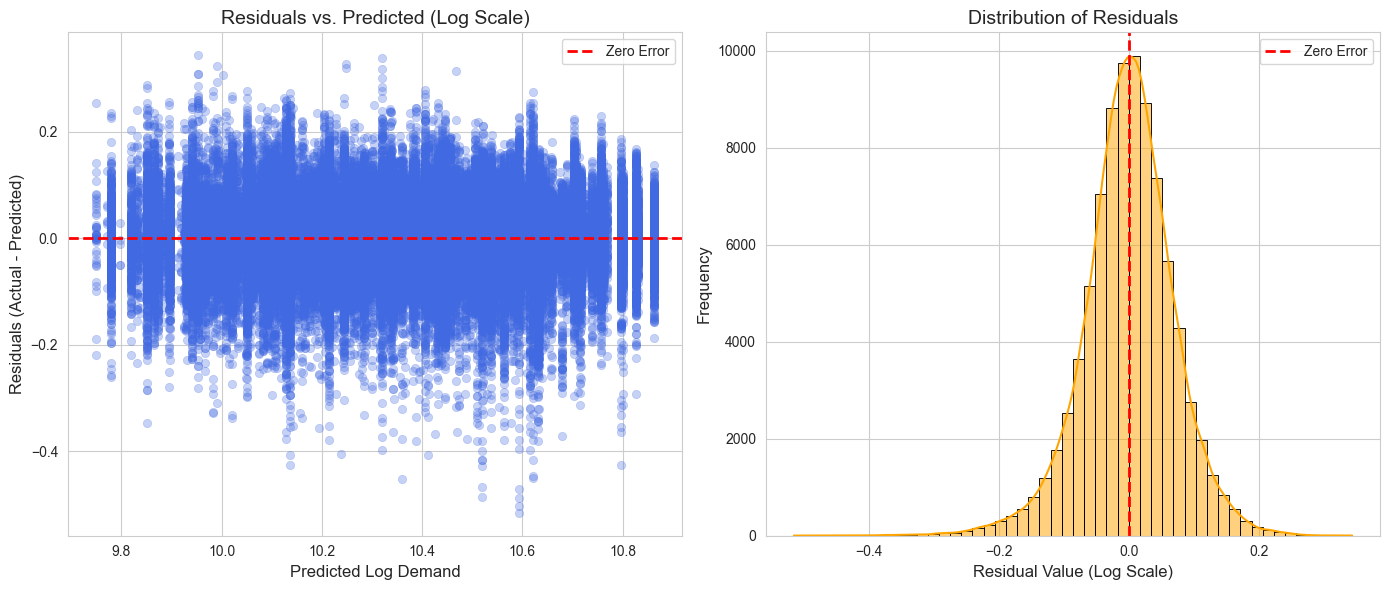


Residuals Summary (Log Scale):
count    86918.0000
mean        -0.0001
std          0.0705
min         -0.5161
25%         -0.0397
50%          0.0014
75%          0.0428
max          0.3441
Name: ND, dtype: float64


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 6b. Residual Analysis (Visualizing Errors) ---
print("\n6b. Generating Residual Plots...")

# 1. Calculate Residuals (Actual Log Demand - Predicted Log Demand)
residuals = y_test - y_pred_log

# Set up the matplotlib figure with two subplots side-by-side
plt.figure(figsize=(14, 6))

# --- Plot 1: Residuals vs. Predicted Values (Homoscedasticity Check) ---
# Este gráfico te dice si el error es constante o si cambia cuando la demanda es muy alta/baja
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.3, color='royalblue', edgecolor=None)

# Add a horizontal line at 0 (Perfect prediction)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.title('Residuals vs. Predicted (Log Scale)', fontsize=14)
plt.xlabel('Predicted Log Demand', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.legend()

# --- Plot 2: Distribution of Residuals (Normality Check) ---
# Este gráfico te dice si los errores siguen una distribución normal (Campana de Gauss)
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=50, color='orange', edgecolor='black')

# Add a vertical line at 0
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')

plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual Value (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# Print statistical summary of residuals
print("\nResiduals Summary (Log Scale):")
print(residuals.describe().round(4))


7. Analyzing Feature Importance...


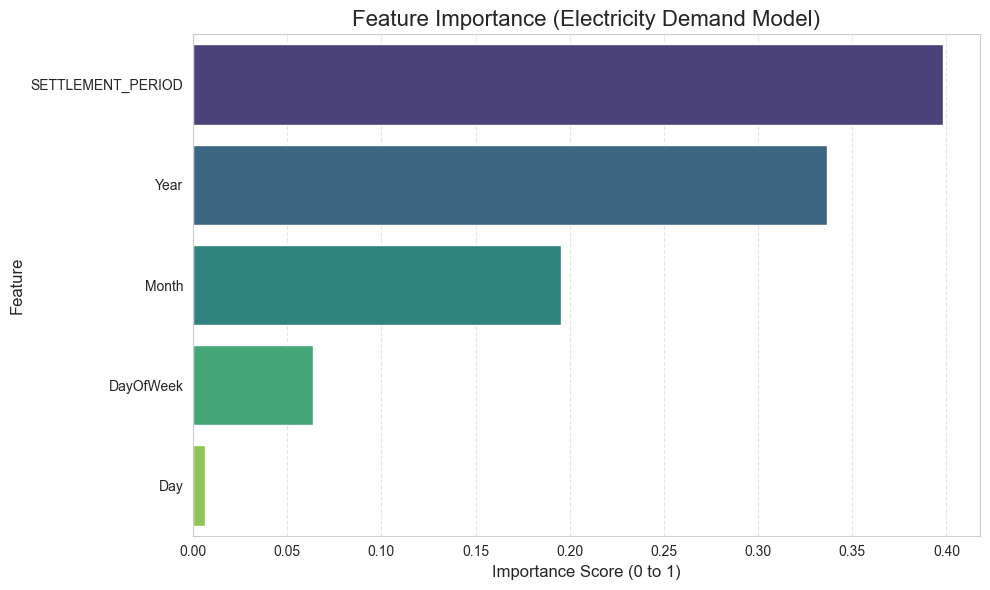


Top Features driving the Demand:
          Feature  Importance (%)
SETTLEMENT_PERIOD           39.79
             Year           33.68
            Month           19.53
        DayOfWeek            6.37
              Day            0.63


In [21]:
# --- 7. Feature Importance Analysis and Visualization ---
print("\n7. Analyzing Feature Importance...")

# 1. Extract importance scores and feature names
importance_scores = dtr_reg.feature_importances_
feature_names = X.columns.tolist()

# 2. Create a DataFrame for sorting and easy plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# 3. Visualization
plt.figure(figsize=(10, 6)) # Ajusté un poco el tamaño para que no sea tan alto innecesariamente

# Nota: Añadimos hue='Feature' y legend=False para evitar advertencias en versiones nuevas de Seaborn
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis', 
    hue='Feature', 
    legend=False
)

plt.title('Feature Importance (Electricity Demand Model)', fontsize=16)
plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Añadir grid vertical suave para leer mejor los valores
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Print readable summary
print("\nTop Features driving the Demand:")
# Mostramos el porcentaje de importancia para que sea más fácil de interpretar
importance_df['Importance (%)'] = (importance_df['Importance'] * 100).round(2)
print(importance_df[['Feature', 'Importance (%)']].to_string(index=False))